Data Loading, EDA & Preprocessing

In [1]:
%pip install -q PySastrawi nltk scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
import nltk

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [2]:
df = pd.read_csv('./Dataset/data.csv', encoding='latin-1')

def create_label(row):
    if row['HS'] == 1:
        return 'Hate Speech'
    elif row['Abusive'] == 1 and row['HS'] == 0:
        return 'Abusive'
    else:
        return 'Neutral'

df['label'] = df.apply(create_label, axis=1)
print("Distribusi Label Dataset:")
print(df['label'].value_counts())

Distribusi Label Dataset:
label
Neutral        5860
Hate Speech    5561
Abusive        1748
Name: count, dtype: int64


In [3]:
slang_df = pd.read_csv('./Dataset/new_kamusalay.csv', encoding='latin-1', header=None)
SLANG_DICT = dict(zip(slang_df[0], slang_df[1]))

factory = StemmerFactory()
stemmer = factory.create_stemmer()
stop_words = set(stopwords.words('indonesian'))

def full_preprocess(text):
    text = str(text).lower()
    text = re.sub(r'\\x[a-f0-9]{2}', ' ', text)
    text = re.sub(r'\b(user|url|rt)\b', ' ', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    text = ' '.join([SLANG_DICT.get(w, w) for w in text.split()])
    text = ' '.join([w for w in text.split() if w not in stop_words])
    text = stemmer.stem(text)
    text = ' '.join([w for w in text.split() if len(w) > 2])
    return text

In [4]:
start_time = time.time()

df['text_clean'] = df['Tweet'].apply(full_preprocess)

print(f"Waktu preprocessing: {(time.time() - start_time) / 60:.2f} menit")
display(df[['Tweet', 'text_clean', 'label']].head())

Waktu preprocessing: 0.05 menit


,Tweet,text_clean,label
0,- disaat semua cowok berusaha melacak perhatia...,cowok usaha lacak perhati gue lantas remeh per...,Hate Speech
1,RT USER: USER siapa yang telat ngasih tau elu?...,telat tau edan sarap gue gaul cigax jifla cal ...,Abusive
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",kadang pikir percaya tuhan jatuh kali kali kad...,Neutral
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,tau mata sipit,Neutral
4,USER USER Kaum cebong kapir udah keliatan dong...,kaum cebong kafir dongok dungu haha,Hate Speech


Data Split

In [5]:
X = df['text_clean']
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Jumlah Data Latih (Train): {X_train_raw.shape[0]}")
print(f"Jumlah Data Uji (Test)  : {X_test_raw.shape[0]}")

Jumlah Data Latih (Train): 10535
Jumlah Data Uji (Test)  : 2634


Feature Engineering (TF-IDF)

In [6]:
tfidf = TfidfVectorizer(ngram_range=(1,2), sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

print(f"Dimensi TF-IDF Train: {X_train_tfidf.shape}")
print(f"Dimensi TF-IDF Test : {X_test_tfidf.shape}")

Dimensi TF-IDF Train: (10535, 78665)
Dimensi TF-IDF Test : (2634, 78665)


Feature Engineering (CountVectorizer)

In [7]:
cvect = CountVectorizer(ngram_range=(1,2))

X_train_count = cvect.fit_transform(X_train_raw)
X_test_count = cvect.transform(X_test_raw)

print(f"Dimensi CountVectorizer Train: {X_train_count.shape}")
print(f"Dimensi CountVectorizer Test : {X_test_count.shape}")

Dimensi CountVectorizer Train: (10535, 78665)
Dimensi CountVectorizer Test : (2634, 78665)


Model Klasifikasi

Naive Bayes (Pakai CountVectorizer)

In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_nb = GridSearchCV(MultinomialNB(), param_grid={'alpha': [0.1, 0.5, 1.0, 2.0]}, cv=skf, scoring='f1_macro', n_jobs=-1)
grid_nb.fit(X_train_count, y_train)

nb_model = grid_nb.best_estimator_
y_pred_nb = nb_model.predict(X_test_count)

results_nb = {
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb, average='macro'),
    'Recall': recall_score(y_test, y_pred_nb, average='macro'),
    'F1 Score': f1_score(y_test, y_pred_nb, average='macro')
}
print(f"Best Alpha NB: {grid_nb.best_params_['alpha']}")

Best Alpha NB: 1.0


K-Nearest Neighbors (Pakai TF-IDF)

In [9]:
grid_knn = GridSearchCV(
    KNeighborsClassifier(metric='cosine', algorithm='brute'), 
    param_grid={'n_neighbors': [3, 5, 7, 9]}, 
    cv=skf, scoring='f1_macro', n_jobs=-1
)
grid_knn.fit(X_train_tfidf, y_train)

knn_model = grid_knn.best_estimator_
y_pred_knn = knn_model.predict(X_test_tfidf)

results_knn = {
    'Model': 'KNN',
    'Accuracy': accuracy_score(y_test, y_pred_knn),
    'Precision': precision_score(y_test, y_pred_knn, average='macro'),
    'Recall': recall_score(y_test, y_pred_knn, average='macro'),
    'F1 Score': f1_score(y_test, y_pred_knn, average='macro')
}
print(f"Best K KNN: {grid_knn.best_params_['n_neighbors']}")

Best K KNN: 9


Logistic Regression (Pakai TF-IDF)

In [10]:
grid_lr = GridSearchCV(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42), 
    param_grid={'C': [0.1, 1, 10, 100]}, 
    cv=skf, scoring='f1_macro', n_jobs=-1
)
grid_lr.fit(X_train_tfidf, y_train)

lr_model = grid_lr.best_estimator_
y_pred_lr = lr_model.predict(X_test_tfidf)

results_lr = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr, average='macro'),
    'Recall': recall_score(y_test, y_pred_lr, average='macro'),
    'F1 Score': f1_score(y_test, y_pred_lr, average='macro')
}
print(f"Best C LR: {grid_lr.best_params_['C']}")

Best C LR: 100


Random Forest (Pakai TF-IDF)

In [11]:
rf_params = {'n_estimators': [100, 200], 'max_depth': [None, 10], 'min_samples_split': [2, 5]}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), 
    param_grid=rf_params, cv=skf, scoring='f1_macro'
)
grid_rf.fit(X_train_tfidf, y_train)

rf_model = grid_rf.best_estimator_
y_pred_rf = rf_model.predict(X_test_tfidf)

results_rf = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf, average='macro'),
    'Recall': recall_score(y_test, y_pred_rf, average='macro'),
    'F1 Score': f1_score(y_test, y_pred_rf, average='macro')
}
print(f"Best Params Random Forest: {grid_rf.best_params_}")

Best Params Random Forest: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


Save Model

In [12]:
import joblib

joblib.dump(lr_model, 'model_lr.pkl')
joblib.dump(nb_model, 'model_nb.pkl')
joblib.dump(rf_model, 'model_rf.pkl')
joblib.dump(knn_model, 'model_knn.pkl')

joblib.dump(tfidf, 'vectorizer_tfidf.pkl')
joblib.dump(cvect, 'vectorizer_count.pkl')

print("Selesai! Semua model sudah terkoneksi dan siap dipakai Streamlit.")

Selesai! Semua model sudah terkoneksi dan siap dipakai Streamlit.


Komparasi Akhir
Hasil Evaluasi Keseluruhan

Tabel Perbandingan Metrik Evaluasi (Keseluruhan Kelas):


,Accuracy,Precision,Recall,F1 Score
Model,,,,
Naive Bayes,0.7779,0.8045,0.7015,0.7290
KNN,0.7198,0.6922,0.6831,0.6864
Logistic Regression,0.7935,0.7725,0.7562,0.7636
Random Forest,0.7954,0.7900,0.7453,0.7627


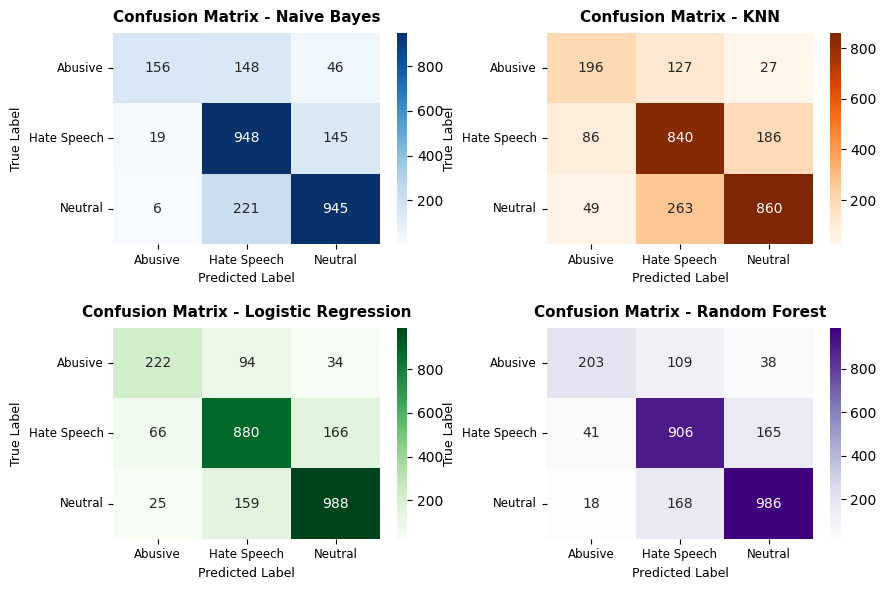

In [13]:
df_results = pd.DataFrame([results_nb, results_knn, results_lr, results_rf])
df_results.set_index('Model', inplace=True)

print("Tabel Perbandingan Metrik Evaluasi (Keseluruhan Kelas):")
display(df_results.style.highlight_max(color='lightgreen').format("{:.4f}"))

fig, axes = plt.subplots(2, 2, figsize=(9, 6))

cms = [
    (confusion_matrix(y_test, y_pred_nb), 'Naive Bayes', axes[0,0], 'Blues'),
    (confusion_matrix(y_test, y_pred_knn), 'KNN', axes[0,1], 'Oranges'),
    (confusion_matrix(y_test, y_pred_lr), 'Logistic Regression', axes[1,0], 'Greens'),
    (confusion_matrix(y_test, y_pred_rf), 'Random Forest', axes[1,1], 'Purples')
]

classes = lr_model.classes_

for cm, title, ax, cmap in cms:
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, 
                xticklabels=classes, yticklabels=classes,
                annot_kws={"size": 10}) 
    
    ax.set_title(f'Confusion Matrix - {title}', fontsize=11, weight='bold', pad=8)
    ax.set_ylabel('True Label', fontsize=9)
    ax.set_xlabel('Predicted Label', fontsize=9)
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=8.5)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

plt.tight_layout()
plt.subplots_adjust(hspace=0.4, wspace=0.3) 

plt.show()

Testing

In [14]:
teks_uji = [
    "Selamat pagi semua, semoga hari ini berjalan lancar dan menyenangkan!", 
    "Woi bangsat, lu kalau bawa motor matanya dipake dong!",               
    "Dasar kaum cebong dungu, pantesan aja negara ini hancur di tangan kalian.", 
    "Makanannya enak banget anjir, wajib cobain kesini besok."             
]

teks_uji_bersih = [full_preprocess(teks) for teks in teks_uji]

vektor_tfidf = tfidf.transform(teks_uji_bersih)
vektor_count = cvect.transform(teks_uji_bersih)

pred_nb = nb_model.predict(vektor_count)
pred_knn = knn_model.predict(vektor_tfidf)
pred_lr = lr_model.predict(vektor_tfidf)
pred_rf = rf_model.predict(vektor_tfidf)

df_testing = pd.DataFrame({
    'Kalimat Asli': teks_uji,
    'Teks Bersih': teks_uji_bersih,
    'Prediksi NB': pred_nb,
    'Prediksi KNN': pred_knn,
    'Prediksi LR': pred_lr,
    'Prediksi RF': pred_rf
})

display(df_testing)

,Kalimat Asli,Teks Bersih,Prediksi NB,Prediksi KNN,Prediksi LR,Prediksi RF
0,"Selamat pagi semua, semoga hari ini berjalan l...",selamat pagi moga jalan lancar senang,Neutral,Neutral,Neutral,Neutral
1,"Woi bangsat, lu kalau bawa motor matanya dipak...",woi bangsat bawa motor mata pakai,Hate Speech,Hate Speech,Hate Speech,Hate Speech
2,"Dasar kaum cebong dungu, pantesan aja negara i...",dasar kaum cebong dungu negara hancur tangan,Hate Speech,Hate Speech,Hate Speech,Hate Speech
3,"Makanannya enak banget anjir, wajib cobain kes...",makan enak banget anjir wajib coba kesini besok,Abusive,Abusive,Abusive,Abusive


Main Program Loop

In [ ]:
def jalankan_prediksi_interaktif():
    print("="*55)
    print("Deteksi Hate Speech & Abusive Language ")
    print("="*55)
    print("Ketik 'keluar' atau 'exit' untuk menghentikan program.\n")
    
    while True:
        teks_input = input("Masukkan kalimat untuk diuji: ")
        
        if teks_input.lower() in ['keluar', 'exit']:
            print("Program dihentikan. Terima kasih!")
            break
            
        if not teks_input.strip():
            print("➢ Kalimat tidak boleh kosong!\n")
            continue
            
        teks_bersih = full_preprocess(teks_input)
        
        vektor_tfidf = tfidf.transform([teks_bersih])
        vektor_count = cvect.transform([teks_bersih])
        
        hasil_nb = nb_model.predict(vektor_count)[0]
        hasil_knn = knn_model.predict(vektor_tfidf)[0]
        hasil_lr = lr_model.predict(vektor_tfidf)[0]
        hasil_rf = rf_model.predict(vektor_tfidf)[0]
 
        print("-" * 45)
        print(f"Teks Asli   : {teks_input}")
        print(f"Teks Bersih : {teks_bersih}")
        print("-" * 45)
        print(f"➢ Naive Bayes         : {hasil_nb}")
        print(f"➢ K-Nearest Neighbors : {hasil_knn}")
        print(f"➢ Logistic Regression : {hasil_lr}")
        print(f"➢ Random Forest       : {hasil_rf}")
        print("-" * 45 + "\n")

jalankan_prediksi_interaktif()

Deteksi Hate Speech & Abusive Language 
Ketik 'keluar' atau 'exit' untuk menghentikan program.

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

➢ Kalimat tidak boleh kosong!

---------------------------------------------
Teks Asli   : enter
Teks Bersih : enter
---------------------------------------------
➢ Naive Bayes         : Neutral
➢ K-Nearest Neighbors : Hate Speech
➢ Logistic Regression : Neutral
➢ Random Forest       : Neutral
---------------------------------------------

